In [3]:
#required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#loading dataset
columns = [
    "Variance",
    "Skewness",
    "Kurtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns
)

#displaying first five samples
df.head()







,Variance,Skewness,Kurtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
#dataset dimensions
print("dimensions of the dataset:")
print(df.shape)

#missing values
print("missing values in the dataset:")
print(df.isnull().sum())

#descriptive statistics
print("descriptive statistics of the dataset:")
print(df.describe())

dimensions of the dataset:
(1372, 5)
missing values in the dataset:
Variance    0
Skewness    0
Kurtosis    0
Entropy     0
Class       0
dtype: int64
descriptive statistics of the dataset:
          Variance     Skewness     Kurtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


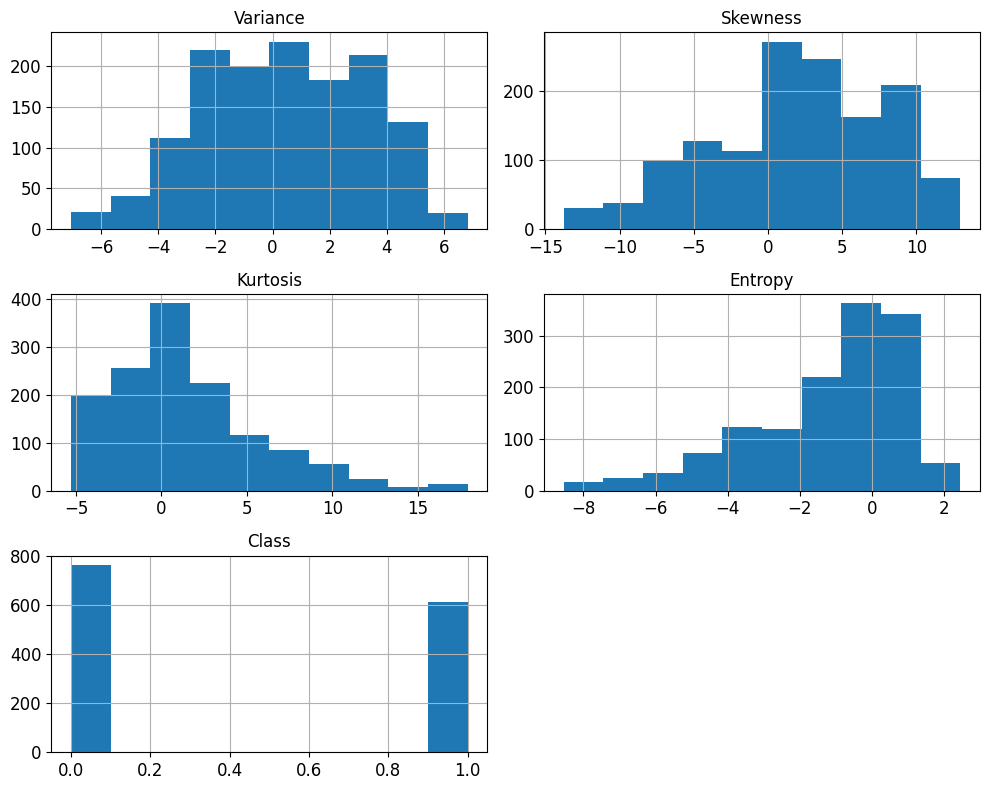

In [49]:
df.hist(figsize=(10,8))

for ax in plt.gcf().axes:
    ax.set_xlabel(
        ax.get_xlabel(),
        fontsize=15,
        fontname='Times New Roman'
    )

    ax.set_ylabel(
        ax.get_ylabel(),
        fontsize=15,
        fontname='Times New Roman'
    )

    ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig(
    "feature_histograms.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

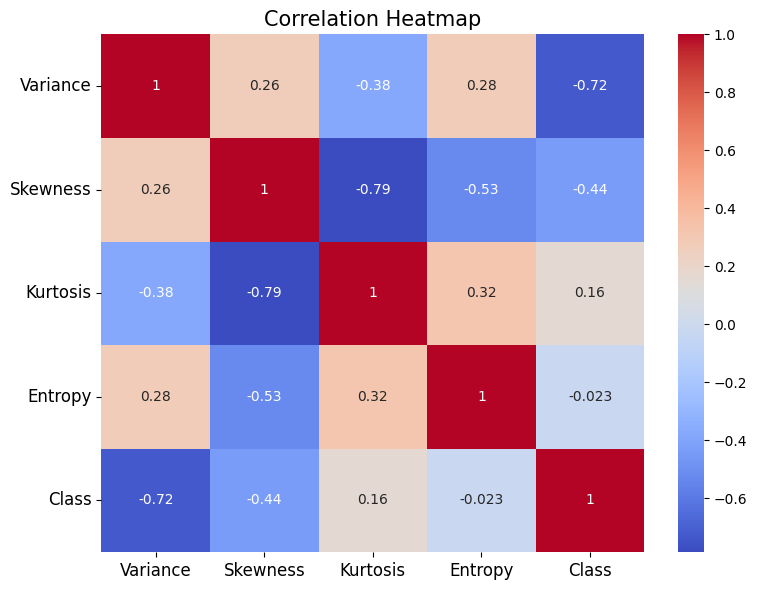

In [50]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap",
    fontsize=15,
    fontname="Times New Roman"
)

plt.xticks(
    fontsize=12,
    fontname="Times New Roman",
    rotation=0
)

plt.yticks(
    fontsize=12,
    fontname="Times New Roman",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "correlation_heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

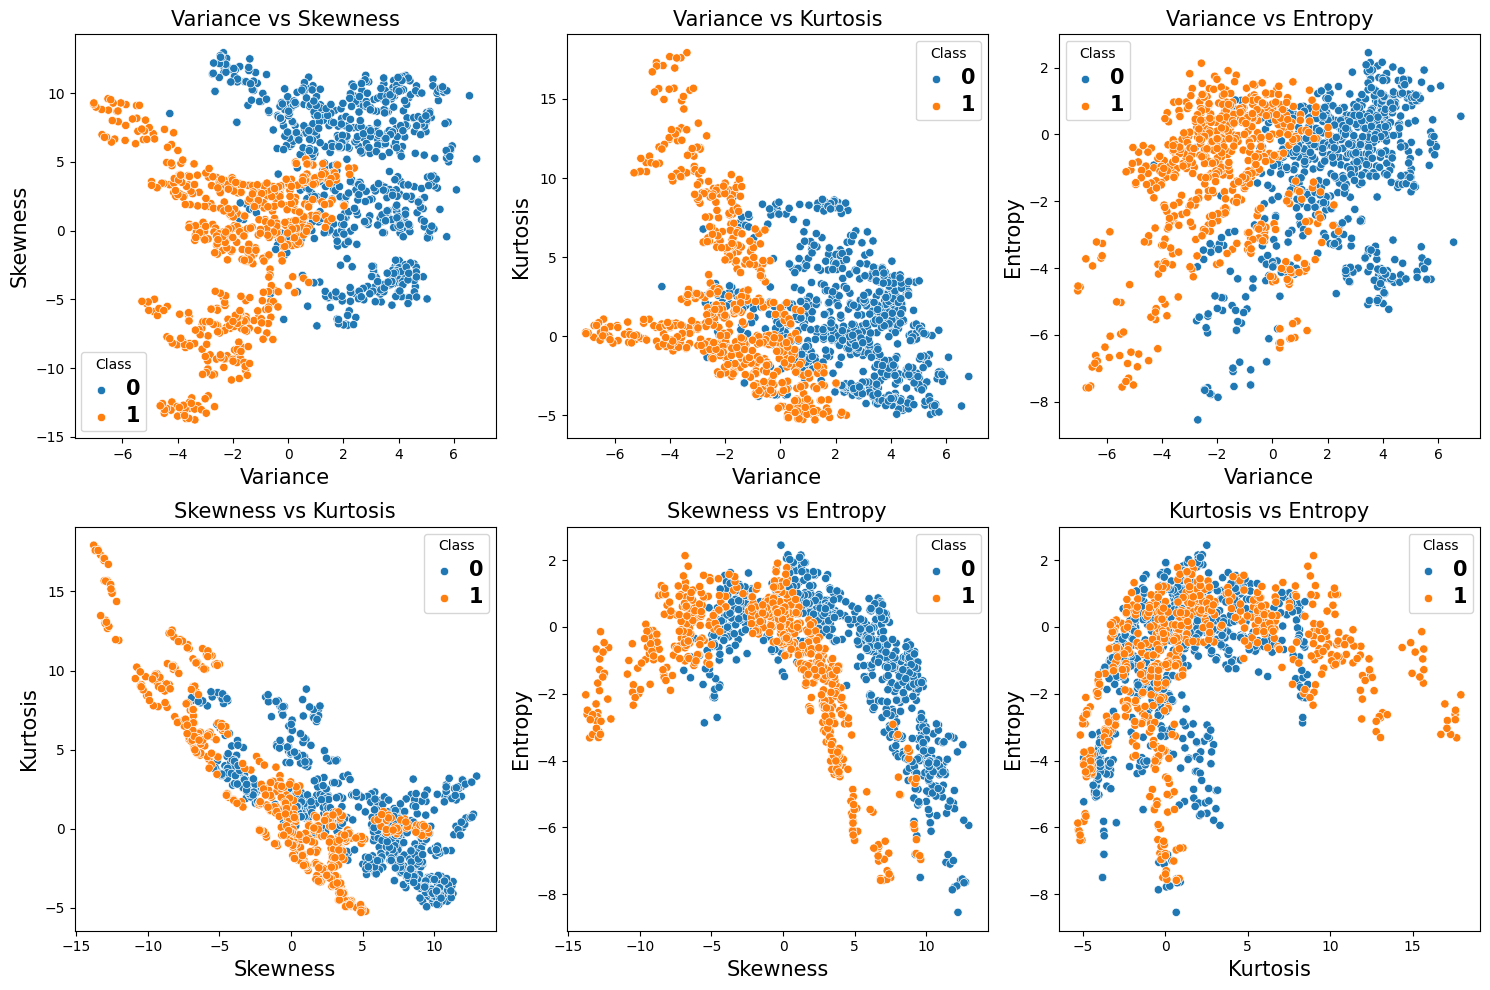

In [51]:
plt.figure(figsize=(15,10))

# Scatter Plot 1
plt.subplot(2,3,1)
sns.scatterplot(
    data=df,
    x='Variance',
    y='Skewness',
    hue='Class'
)
plt.title("Variance vs Skewness", fontsize=15)
plt.xlabel("Variance", fontsize=15)
plt.ylabel("Skewness", fontsize=15)

# Scatter Plot 2
plt.subplot(2,3,2)
sns.scatterplot(
    data=df,
    x='Variance',
    y='Kurtosis',
    hue='Class'
)
plt.title("Variance vs Kurtosis", fontsize=15)
plt.xlabel("Variance", fontsize=15)
plt.ylabel("Kurtosis", fontsize=15)

# Scatter Plot 3
plt.subplot(2,3,3)
sns.scatterplot(
    data=df,
    x='Variance',
    y='Entropy',
    hue='Class'
)
plt.title("Variance vs Entropy", fontsize=15)
plt.xlabel("Variance", fontsize=15)
plt.ylabel("Entropy", fontsize=15)

# Scatter Plot 4
plt.subplot(2,3,4)
sns.scatterplot(
    data=df,
    x='Skewness',
    y='Kurtosis',
    hue='Class'
)
plt.title("Skewness vs Kurtosis", fontsize=15)
plt.xlabel("Skewness", fontsize=15)
plt.ylabel("Kurtosis", fontsize=15)

# Scatter Plot 5
plt.subplot(2,3,5)
sns.scatterplot(
    data=df,
    x='Skewness',
    y='Entropy',
    hue='Class'
)
plt.title("Skewness vs Entropy", fontsize=15)
plt.xlabel("Skewness", fontsize=15)
plt.ylabel("Entropy", fontsize=15)

# Scatter Plot 6
plt.subplot(2,3,6)
sns.scatterplot(
    data=df,
    x='Kurtosis',
    y='Entropy',
    hue='Class'
)
plt.title("Kurtosis vs Entropy", fontsize=15)
plt.xlabel("Kurtosis", fontsize=15)
plt.ylabel("Entropy", fontsize=15)

# Make legends bold
for ax in plt.gcf().axes:
    legend = ax.get_legend()
    if legend:
        plt.setp(
            legend.get_texts(),
            fontsize=15,
            fontweight='bold'
        )

plt.tight_layout()

plt.savefig(
    "scatter_plot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

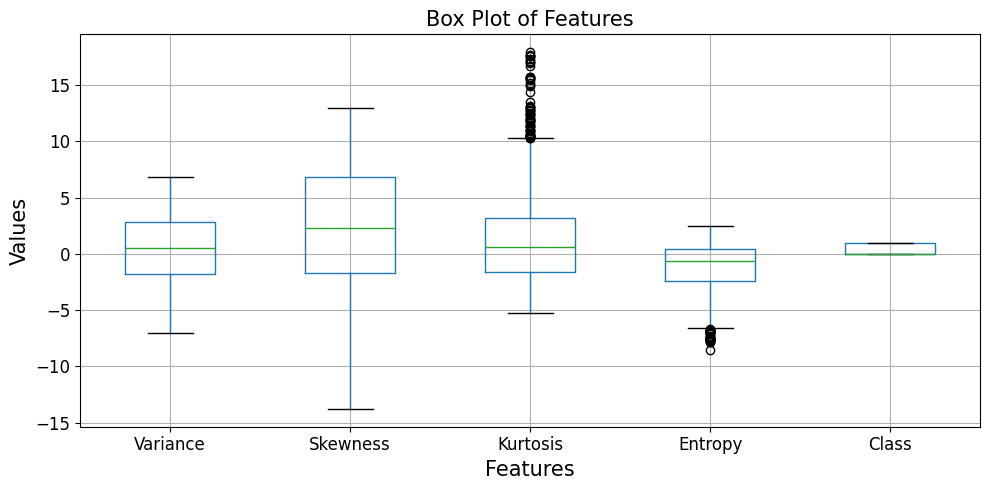

In [52]:
# Box Plot

plt.figure(figsize=(10,5))

df.boxplot()

plt.title(
    "Box Plot of Features",
    fontsize=15
)

plt.xlabel(
    "Features",
    fontsize=15
)

plt.ylabel(
    "Values",
    fontsize=15
)

plt.xticks(
    fontsize=12,
    rotation=0
)

plt.yticks(
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "boxplots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [26]:
# splitting features and labels

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# train-test split FIRST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# normalization AFTER splitting

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, z):

        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.errors_history = []
        self.weight_history = []
        self.bias_history = []

        print("="*70)
        print("INITIAL PARAMETERS")
        print("="*70)

        print("Initial Weights :", self.weights)
        print("Initial Bias :", self.bias)

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                z = np.dot(xi, self.weights) + self.bias

                y_pred = self.activation(z)

                update = self.lr * (target - y_pred)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors_history.append(errors)

            self.weight_history.append(
                self.weights.copy()
            )

            self.bias_history.append(
                self.bias
            )

            print("\n")
            print("-"*60)
            print(f"Epoch {epoch+1}")
            print("-"*60)

            print("Misclassified Samples :", errors)
            print("Weights :", self.weights)
            print("Bias :", self.bias)

        print("\n")
        print("="*70)
        print("FINAL PARAMETERS")
        print("="*70)

        print("Final Weights :", self.weights)
        print("Final Bias :", self.bias)

    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.activation(z)

In [43]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(X_train, y_train)

    results[lr] = model.errors_history

INITIAL PARAMETERS
Initial Weights : [0. 0. 0. 0.]
Initial Bias : 0


------------------------------------------------------------
Epoch 1
------------------------------------------------------------
Misclassified Samples : 51
Weights : [-0.00602491 -0.00840769 -0.00630001  0.00022686]
Bias : -0.003


------------------------------------------------------------
Epoch 2
------------------------------------------------------------
Misclassified Samples : 32
Weights : [-0.00862507 -0.01021529 -0.00766379  0.00073922]
Bias : -0.003


------------------------------------------------------------
Epoch 3
------------------------------------------------------------
Misclassified Samples : 27
Weights : [-0.00993244 -0.01133076 -0.00819755  0.0005451 ]
Bias : -0.004


------------------------------------------------------------
Epoch 4
------------------------------------------------------------
Misclassified Samples : 25
Weights : [-0.00798824 -0.01184065 -0.01063295 -0.00073229]
Bias : -0.005


In [47]:
weights = np.array(
    model.weight_history
)

epoch_table = pd.DataFrame({

    "Epoch":
        range(
            1,
            len(model.errors_history)+1
        ),

    "Errors":
        model.errors_history,

    "Weight1":
        weights[:,0],

    "Weight2":
        weights[:,1],

    "Weight3":
        weights[:,2],

    "Weight4":
        weights[:,3],

    "Bias":
        model.bias_history
})

print(epoch_table)

    Epoch  Errors   Weight1   Weight2   Weight3   Weight4  Bias
0       1      51 -0.602491 -0.840769 -0.630001  0.022686  -0.3
1       2      32 -0.862507 -1.021529 -0.766379  0.073922  -0.3
2       3      27 -0.993244 -1.133076 -0.819755  0.054510  -0.4
3       4      25 -0.798824 -1.184065 -1.063295 -0.073229  -0.5
4       5      27 -1.098676 -1.248832 -1.030505 -0.068150  -0.4
..    ...     ...       ...       ...       ...       ...   ...
95     96      16 -2.278475 -2.653598 -2.439879 -0.315703  -1.1
96     97      12 -2.278879 -2.621284 -2.464235 -0.266813  -1.1
97     98      13 -2.179867 -2.697925 -2.448654 -0.097892  -1.2
98     99      15 -2.270838 -2.651243 -2.439547 -0.285564  -1.1
99    100      18 -2.229840 -2.690353 -2.464967 -0.043861  -1.1

[100 rows x 7 columns]


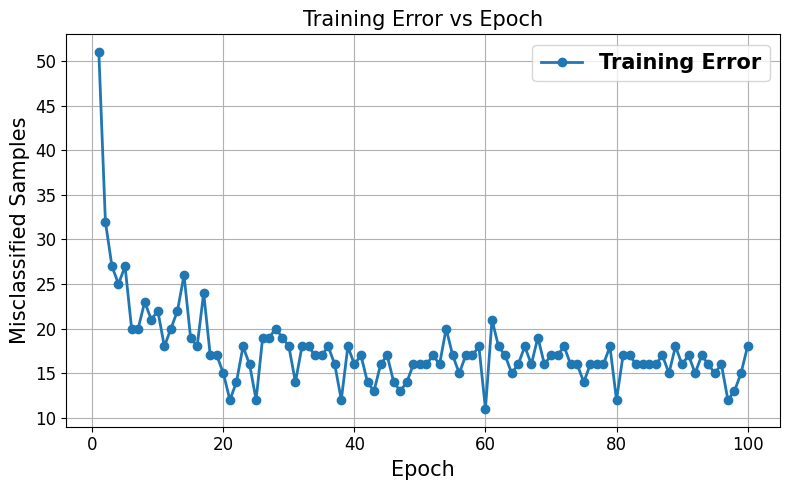

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(model.errors_history)+1),
    model.errors_history,
    marker='o',
    linewidth=2,
    label='Training Error'
)

plt.xlabel(
    "Epoch",
    fontsize=15
)

plt.ylabel(
    "Misclassified Samples",
    fontsize=15
)

plt.title(
    "Training Error vs Epoch",
    fontsize=15
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    prop={
        'size':15,
        'weight':'bold'
    }
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_error_vs_epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

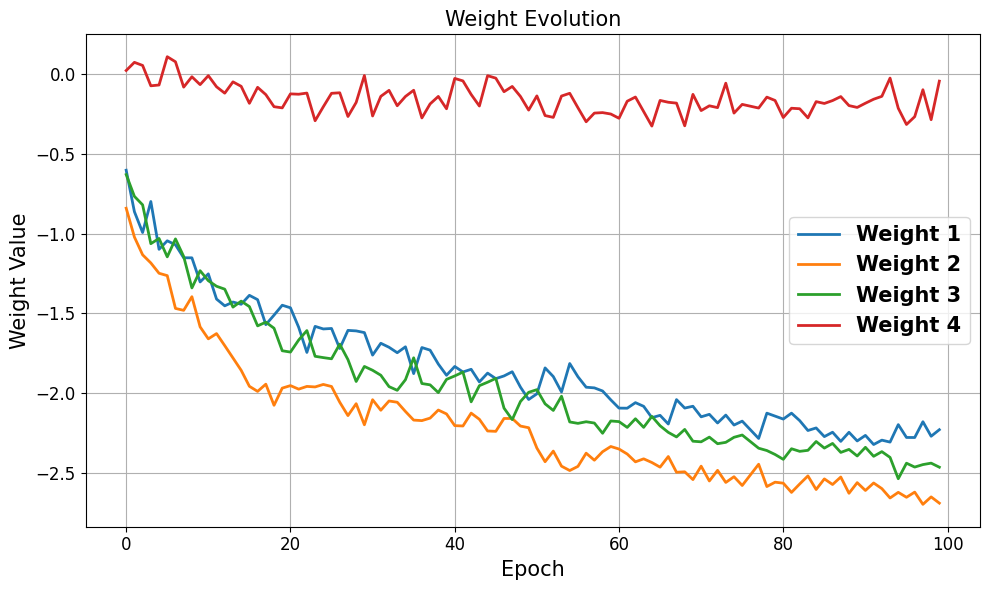

In [54]:
weights = np.array(model.weight_history)

plt.figure(figsize=(10,6))

for i in range(weights.shape[1]):

    plt.plot(
        weights[:, i],
        linewidth=2,
        label=f'Weight {i+1}'
    )

plt.xlabel(
    "Epoch",
    fontsize=15
)

plt.ylabel(
    "Weight Value",
    fontsize=15
)

plt.title(
    "Weight Evolution",
    fontsize=15
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    prop={
        'size':15,
        'weight':'bold'
    }
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "weight_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

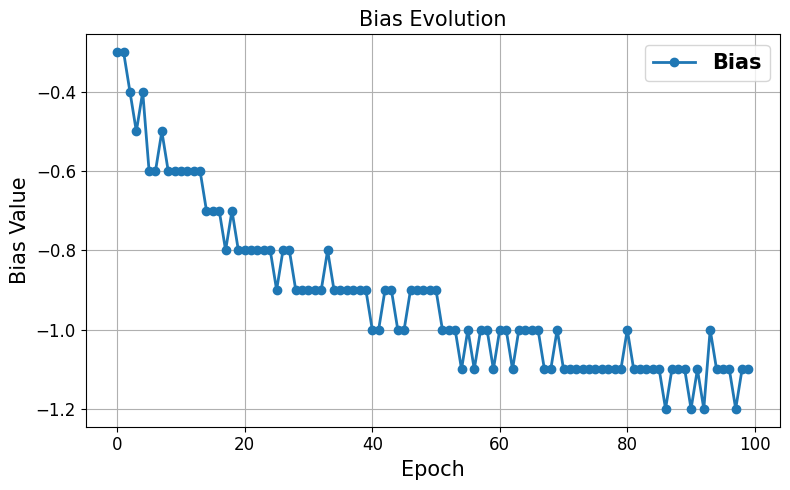

In [55]:
plt.figure(figsize=(8,5))

plt.plot(
    model.bias_history,
    marker='o',
    linewidth=2,
    label='Bias'
)

plt.xlabel(
    "Epoch",
    fontsize=15
)

plt.ylabel(
    "Bias Value",
    fontsize=15
)

plt.title(
    "Bias Evolution",
    fontsize=15
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    prop={
        'size':15,
        'weight':'bold'
    }
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

[[149   4]
 [  0 122]]


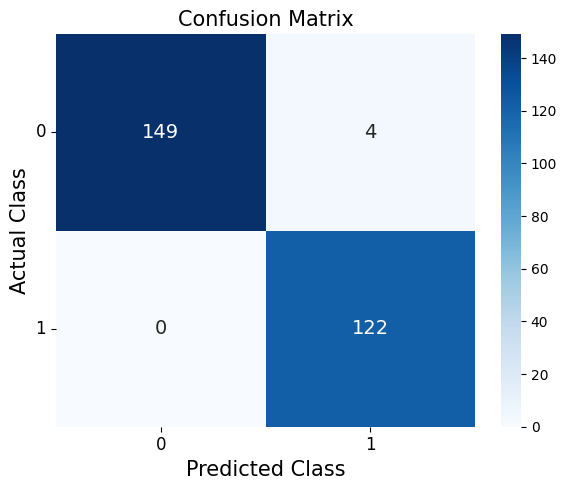

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size":14}
)

plt.xlabel(
    "Predicted Class",
    fontsize=15
)

plt.ylabel(
    "Actual Class",
    fontsize=15
)

plt.title(
    "Confusion Matrix",
    fontsize=15
)

plt.xticks(
    fontsize=12
)

plt.yticks(
    fontsize=12,
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9854545454545455
Precision : 0.9682539682539683
Recall : 1.0
F1 Score : 0.9838709677419355


In [37]:
summary = pd.DataFrame({

    "Metric":[
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        len(df),
        "80/20",
        model.lr,
        model.epochs,
        str(model.weights),
        model.bias,
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(summary)

             Metric                                              Value
0      Dataset Size                                               1372
1  Train/Test Split                                              80/20
2     Learning Rate                                               0.01
3            Epochs                                                100
4     Final Weights  [-0.22298399 -0.26903532 -0.24649669 -0.00438611]
5        Final Bias                                              -0.11
6          Accuracy                                           0.985455
7         Precision                                           0.968254
8            Recall                                                1.0
9          F1 Score                                           0.983871


In [41]:
# Select only two features

X2 = df[['Variance', 'Skewness']].values
y2 = df['Class'].values

# Train-Test Split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

# Standardization

from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

# Train Perceptron

model2 = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model2.fit(
    X_train2,
    y_train2
)

INITIAL PARAMETERS
Initial Weights : [0. 0.]
Initial Bias : 0


------------------------------------------------------------
Epoch 1
------------------------------------------------------------
Misclassified Samples : 194
Weights : [-0.01419646 -0.02177112]
Bias : 3.469446951953614e-18


------------------------------------------------------------
Epoch 2
------------------------------------------------------------
Misclassified Samples : 196
Weights : [-0.01674365 -0.02537041]
Bias : 3.469446951953614e-18


------------------------------------------------------------
Epoch 3
------------------------------------------------------------
Misclassified Samples : 196
Weights : [-0.01040362 -0.01663377]
Bias : 3.469446951953614e-18


------------------------------------------------------------
Epoch 4
------------------------------------------------------------
Misclassified Samples : 198
Weights : [-0.0208845  -0.02857099]
Bias : 3.469446951953614e-18


------------------------------------

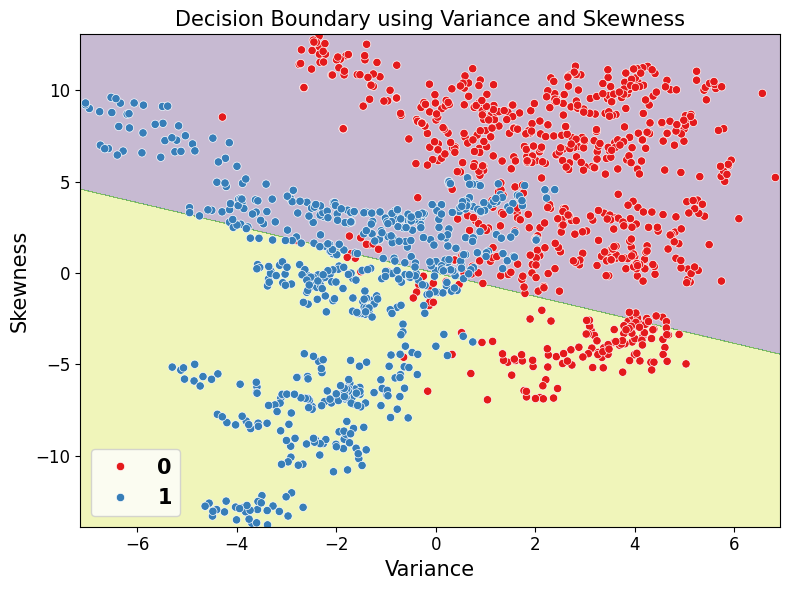

In [57]:
x_min, x_max = X2[:,0].min()-0.1, X2[:,0].max()+0.1

y_min, y_max = X2[:,1].min()-0.1, X2[:,1].max()+0.1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model2.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

sns.scatterplot(
    x=X2[:,0],
    y=X2[:,1],
    hue=y2,
    palette='Set1'
)

plt.xlabel(
    "Variance",
    fontsize=15
)

plt.ylabel(
    "Skewness",
    fontsize=15
)

plt.title(
    "Decision Boundary using Variance and Skewness",
    fontsize=15
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    prop={
        'size':15,
        'weight':'bold'
    }
)

plt.tight_layout()

plt.savefig(
    "decision_boundary.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()